In [2]:
import re
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor
from procompa import get_project_root

PRJ_ROOT = get_project_root()
data_dir = PRJ_ROOT / "data"

In [3]:
%config InlineBackend.figure_format = "retina"

How much shorter are the inputs

In [3]:
base_19 = data_dir / "Pipeline/19_CP_pae_plddt_trimmed/CombFold"
base_20 = data_dir / "Pipeline/20_CP_pae_plddt_trimmed_interface_safeguard/CombFold"


CA_PATTERN = re.compile(rb"^ATOM.{8} CA [ A]", re.MULTILINE)


def count_ca(pdb_path):
    with open(pdb_path, "rb") as f:
        return len(CA_PATTERN.findall(f.read()))


def find_pairs(base, subdir):
    """One pdb path per unique pair (only directory listings, no file reading)."""
    pairs = {}
    for pool_dir in sorted(base.glob("*_pool_input")):
        for pdb in (pool_dir / subdir).glob("AFM_*_unrelaxed_rank_1_*.pdb"):
            pair = pdb.name.removeprefix("AFM_").split("_unrelaxed")[0]
            pairs.setdefault(pair, pdb)  # keep first occurrence
    assert len(pairs) > 0, f"no pdbs found in {base}/*_pool_input/{subdir}"
    return pairs


def count_all(pairs):
    """Count CA atoms for all pdbs in parallel (processes, not threads -> no GIL limit)."""
    with ProcessPoolExecutor(max_workers=32) as ex:
        counts = list(ex.map(count_ca, pairs.values(), chunksize=16))
    return dict(zip(pairs.keys(), counts))


In [ ]:
pairs_untrimmed = find_pairs(base_19, "pdbs_untrimmed")
pairs_trimmed = find_pairs(base_19, "pdbs")
pairs_safeguard = find_pairs(base_20, "pdbs")  

print(f"untrimmed: {len(pairs_untrimmed)}, trimmed: {len(pairs_trimmed)}, safeguard: {len(pairs_safeguard)}")

untrimmed: 6837, trimmed: 6837, safeguard: 6838


AssertionError: safeguard / trimmed pair sets differ

In [ ]:
pairs_safeguard

In [ ]:
len_untrimmed = count_all(pairs_untrimmed)
len_trimmed = count_all(pairs_trimmed)
len_safeguard = count_all(pairs_safeguard)

In [5]:
pdb_length = pdb_length.with_columns(
    removed_relative = pl.col("n_removed")/pl.col("length_untrimmed")
)

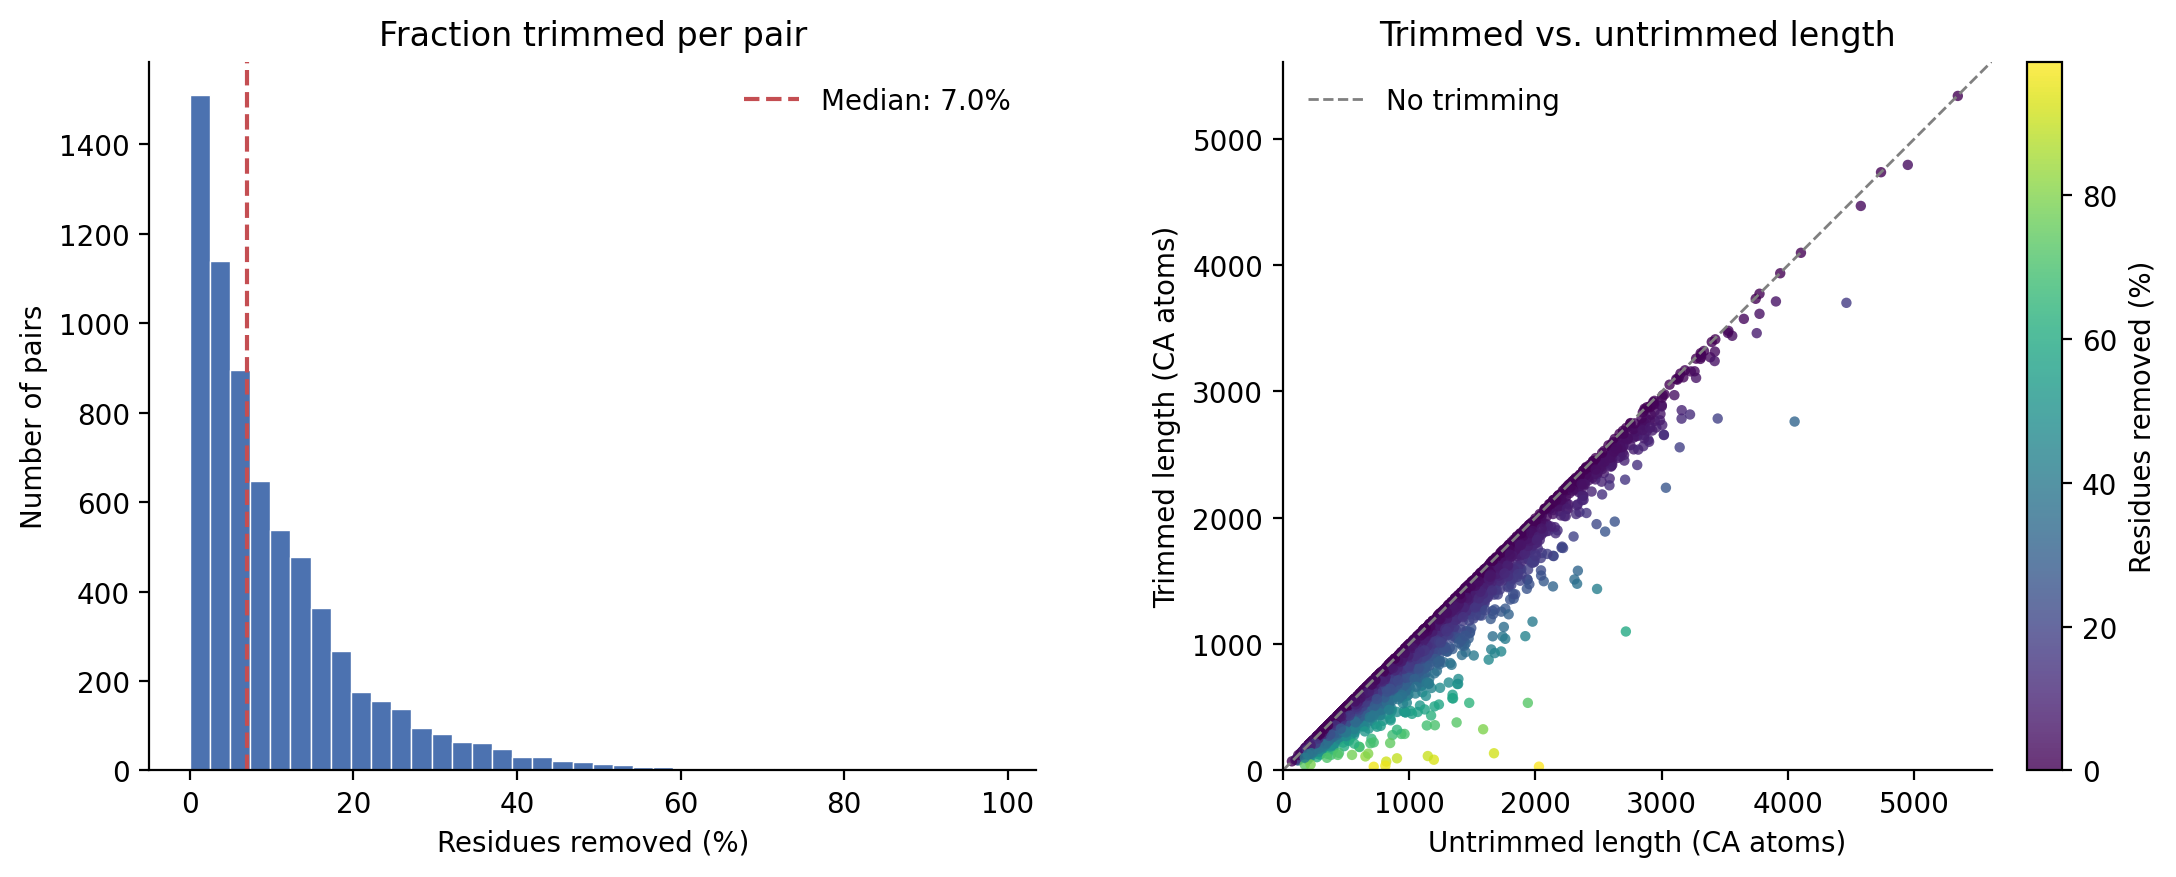

In [6]:
rel = pdb_length["removed_relative"].to_numpy()
untr = pdb_length["length_untrimmed"].to_numpy()
tr = pdb_length["length_trimmed"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: distribution of fraction removed
ax = axes[0]
ax.hist(rel * 100, bins=40, color="#4C72B0", edgecolor="white", linewidth=0.5)
med = np.median(rel) * 100
ax.axvline(med, color="#C44E52", linestyle="--", linewidth=1.5,
           label=f"Median: {med:.1f}%")
ax.set_xlabel("Residues removed (%)")
ax.set_ylabel("Number of pairs")
ax.set_title("Fraction trimmed per pair")
ax.legend(frameon=False)

# Right: trimmed vs untrimmed length, coloured by fraction removed
ax = axes[1]
sc = ax.scatter(untr, tr, c=rel * 100, cmap="viridis", s=14, alpha=0.8,
                edgecolors="none")
lim = max(untr.max(), tr.max()) * 1.05
ax.plot([0, lim], [0, lim], color="grey", linestyle="--", linewidth=1,
        label="No trimming")
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_aspect("equal")
ax.set_xlabel("Untrimmed length (CA atoms)")
ax.set_ylabel("Trimmed length (CA atoms)")
ax.set_title("Trimmed vs. untrimmed length")
ax.legend(frameon=False, loc="upper left")
cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Residues removed (%)")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

is there a diff between homo- and heterodimer

In [7]:
parts = pl.col("pair").str.split("_")

pdb_length = pdb_length.with_columns(
    pl.when(parts.list.get(0) == parts.list.get(1))
    .then(pl.lit("homo"))
    .otherwise(pl.lit("hetero"))
    .alias("pair_type")
)

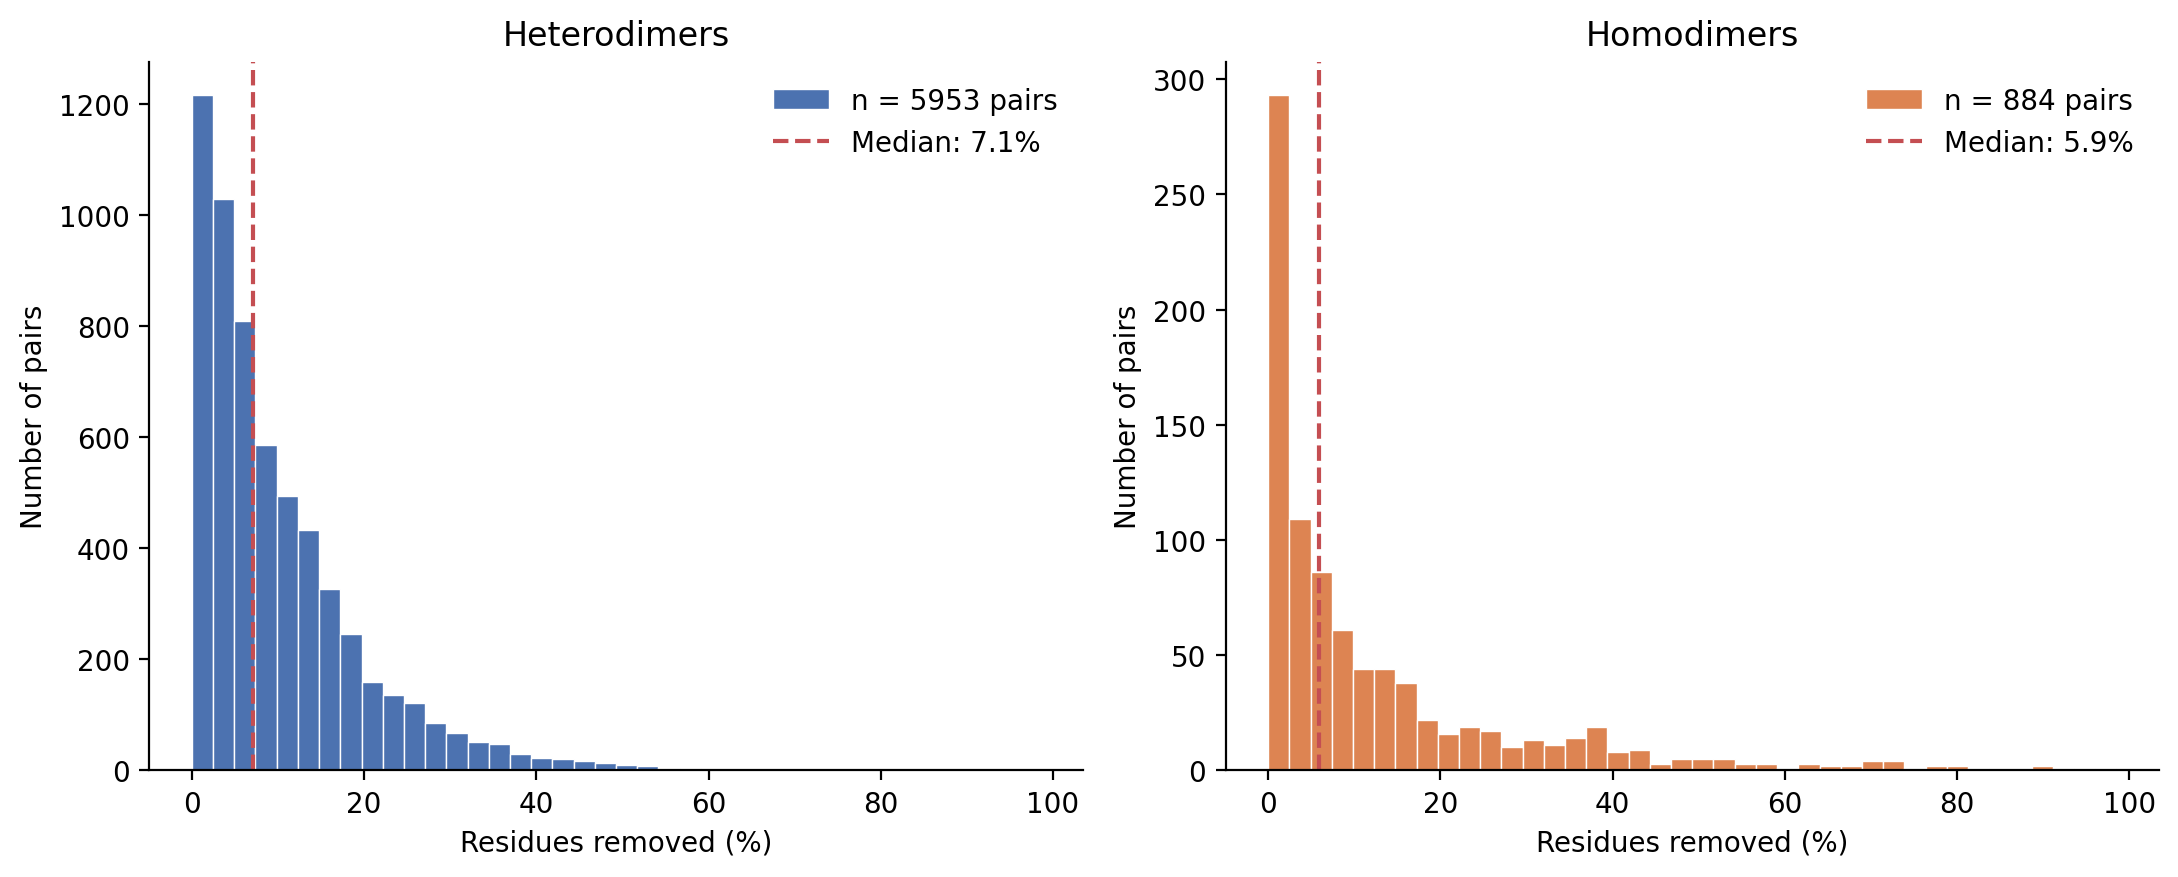

In [8]:
pair_type = pdb_length["pair_type"].to_numpy()

groups = [
    ("hetero", "Heterodimers", "#4C72B0"),
    ("homo", "Homodimers", "#DD8452"),
]

bins = np.linspace(0, rel.max() * 100, 41)  # same bins for both panels

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True)

for ax, (key, name, color) in zip(axes, groups):
    vals = rel[pair_type == key] * 100
    assert len(vals) > 0, f"no pairs with pair_type == {key!r}"

    ax.hist(vals, bins=bins, color=color, edgecolor="white", linewidth=0.5,
            label=f"n = {len(vals)} pairs")
    med = np.median(vals)
    ax.axvline(med, color="#C44E52", linestyle="--", linewidth=1.5,
               label=f"Median: {med:.1f}%")

    ax.set_xlabel("Residues removed (%)")
    ax.set_ylabel("Number of pairs")
    ax.set_title(name)
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

Did trimming the inputs allowed for more succesful assemblies

higher confidence? as i woud expect?

did it change the tm score?

In [ ]:
def add_confidence(df: pl.DataFrame) -> pl.DataFrame:
    conf = {}
    for d in {Path(p).parent for p in df["combfold_output_path"]}:
        with open(d / "confidence.txt") as f:
            conf.update({k: float(v) for k, v in (line.split() for line in f if line.strip())})

    return df.with_columns(
        pl.col("combfold_output_path")
        .replace_strict(conf, return_dtype=pl.Float64)
        .alias("CF_confidence")
    )

def load(folder: str) -> pl.DataFrame:
    df = add_confidence(
        pl.read_parquet(data_dir / "Pipeline" / folder / "cf_pdb_structure_similarity/cf_pdb_eval_all_metrics.parquet")
    )
    return (
        df.filter(pl.col("n_proteins") > 2)
        .sort("CF_confidence", descending=True)
        .group_by("complex_ac")
        .first()
    )


ranking_TM, iptm_TM, ptm_avg_TM, pae_TM = map(load, [
    "10_all_CP_complexes",
    "16_CP_model_based_on_iptm",
    "17_CP_model_based_on_ptm_avg",
    "18_CP_model_based_on_pae",
])